# Crop Doctor Notebook

---
### Steps
1. GPU + setup
2. Download dataset
3. Build `tf.data` pipeline
4. Build model with label smoothing
5. Phase 1 — train head (5 epochs)
6. Phase 2 — fine-tune (8 epochs)
7. Calibrate OOD thresholds
8. Test-Time Augmentation predictor
9. Test with plant + non-plant images
10. Save model
11. Download

## Step 1 — GPU + Setup

In [ ]:
import tensorflow as tf
import numpy as np
import os, json, random, io

print('TensorFlow:', tf.__version__)
import keras
print('Keras     :', keras.__version__)

gpus = tf.config.list_physical_devices('GPU')
print('GPUs:', gpus)

if not gpus:
    print('\n NO GPU → Runtime > Change runtime type > T4 GPU')
else:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    print(' GPU ready')

tf.random.set_seed(42)
np.random.seed(42)

TensorFlow: 2.19.0
Keras     : 3.13.2
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
✅ GPU ready


In [ ]:
!pip install -q kaggle scikit-learn matplotlib seaborn pillow

## Step 2 — Download Dataset

In [ ]:
from google.colab import files
print('Upload kaggle.json:')
files.upload()

Upload kaggle.json:


Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"tanjidnafis","key":"c78ea6fcacba0611361398125ae0da83"}'}

In [ ]:
os.makedirs('/root/.kaggle', exist_ok=True)
!mv kaggle.json /root/.kaggle/ && chmod 600 /root/.kaggle/kaggle.json
!kaggle datasets download -d abdallahalidev/plantvillage-dataset
!unzip -q plantvillage-dataset.zip -d plantvillage
print('✅ Dataset ready')

Dataset URL: https://www.kaggle.com/datasets/abdallahalidev/plantvillage-dataset
License(s): CC-BY-NC-SA-4.0
100% 2.04G/2.04G [00:21<00:00, 100MB/s] 

✅ Dataset ready


In [ ]:
BASE_DIR = '/content/plantvillage/plantvillage dataset/color'
classes  = sorted(os.listdir(BASE_DIR))
NUM_CLASSES = len(classes)

class_to_idx = {c: i for i, c in enumerate(classes)}
idx_to_class = {i: c for i, c in enumerate(classes)}

total  = sum(len(os.listdir(os.path.join(BASE_DIR, c))) for c in classes)
counts = [len(os.listdir(os.path.join(BASE_DIR, c))) for c in classes]

print(f'Classes  : {NUM_CLASSES}')
print(f'Images   : {total:,}')
print(f'Min/class: {min(counts)}')
print(f'Max/class: {max(counts)}')

class_names_export = {str(i): c for i, c in idx_to_class.items()}
with open('class_names.json', 'w') as f:
    json.dump(class_names_export, f, indent=2)
print('\nclass_names.json saved')

Classes  : 38
Images   : 54,305
Min/class: 152
Max/class: 5507

class_names.json saved


##  Step 3 — tf.data Pipeline

In [ ]:
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

IMG_SIZE   = 224
BATCH_SIZE = 32
AUTOTUNE   = tf.data.AUTOTUNE

all_paths, all_labels = [], []
for cls in classes:
    cls_dir = os.path.join(BASE_DIR, cls)
    for fname in os.listdir(cls_dir):
        if fname.lower().endswith(('.jpg', '.jpeg', '.png')):
            all_paths.append(os.path.join(cls_dir, fname))
            all_labels.append(class_to_idx[cls])

all_paths  = np.array(all_paths)
all_labels = np.array(all_labels)

idx = np.random.permutation(len(all_paths))
all_paths, all_labels = all_paths[idx], all_labels[idx]

split = int(0.8 * len(all_paths))
train_paths, val_paths   = all_paths[:split],  all_paths[split:]
train_labels, val_labels = all_labels[:split], all_labels[split:]

print(f'Train: {len(train_paths):,}   Val: {len(val_paths):,}')

Train: 43,444   Val: 10,861


In [ ]:
@tf.function
def load_image(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    img = tf.cast(img, tf.float32)
    img = preprocess_input(img)
    label = tf.one_hot(label, NUM_CLASSES)
    return img, label

@tf.function
def augment(img, label):
    img = tf.image.random_flip_left_right(img)
    img = tf.image.random_flip_up_down(img)
    k   = tf.random.uniform([], 0, 4, dtype=tf.int32)
    img = tf.image.rot90(img, k)
    img = tf.image.random_brightness(img, max_delta=0.2)
    img = tf.image.random_contrast(img, 0.8, 1.2)
    img = tf.image.random_saturation(img, 0.8, 1.2)
    img = tf.clip_by_value(img, -1.0, 1.0)
    return img, label

train_ds = (
    tf.data.Dataset.from_tensor_slices((train_paths, train_labels))
    .shuffle(len(train_paths), seed=42)
    .map(load_image,  num_parallel_calls=AUTOTUNE)
    .map(augment,     num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

val_ds = (
    tf.data.Dataset.from_tensor_slices((val_paths, val_labels))
    .map(load_image,  num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

print('tf.data pipeline ready')
print(f'Train batches: {len(train_ds)}')
print(f'Val batches  : {len(val_ds)}')

tf.data pipeline ready
Train batches: 1358
Val batches  : 340


In [ ]:
from sklearn.utils.class_weight import compute_class_weight

cw = compute_class_weight('balanced', classes=np.arange(NUM_CLASSES), y=train_labels)
class_weight_dict = dict(enumerate(cw))
print(f'Class weights: min={min(cw):.3f}  max={max(cw):.3f}')

Class weights: min=0.260  max=9.002


## Step 4 — Build Model with Label Smoothing

In [ ]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import (
    GlobalAveragePooling2D, Dense, Dropout,
    BatchNormalization, Input
)
from tensorflow.keras.models import Model

def build_model(num_classes, trainable_base=False):
    inputs = Input(shape=(224, 224, 3))

    base = MobileNetV2(
        input_shape=(224, 224, 3),
        include_top=False,
        weights='imagenet'
    )
    base.trainable = trainable_base

    x = base(inputs, training=False)
    x = GlobalAveragePooling2D()(x)
    x = BatchNormalization()(x)
    x = Dense(512, activation='relu')(x)
    x = Dropout(0.4)(x)
    x = Dense(256, activation='relu')(x)
    x = Dropout(0.3)(x)
    outputs = Dense(num_classes, activation='softmax')(x)

    return Model(inputs, outputs), base

model, base_model = build_model(NUM_CLASSES, trainable_base=False)

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=[
        'accuracy',
        tf.keras.metrics.TopKCategoricalAccuracy(k=3, name='top3')
    ]
)

print(f'Total params : {model.count_params():,}')
print(f'Trainable    : {sum(tf.size(w).numpy() for w in model.trainable_weights):,}')

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Total params : 3,060,070
Trainable    : 799,526


## Step 5 — Phase 1: Train Head (5 epochs)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

cb1 = [
    EarlyStopping(monitor='val_accuracy', patience=3,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                      patience=2, min_lr=1e-7, verbose=1),
    ModelCheckpoint('ckpt_phase1.keras', monitor='val_accuracy',
                    save_best_only=True, verbose=1)
]

print('Phase 1 — training classification head...')
history1 = model.fit(
    train_ds,
    epochs=5,
    validation_data=val_ds,
    callbacks=cb1,
    class_weight=class_weight_dict,
    verbose=1
)

p1_best = max(history1.history['val_accuracy'])
print(f'\nPhase 1 best val accuracy: {p1_best*100:.2f}%')

Phase 1 — training classification head...
Epoch 1/5
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - accuracy: 0.6116 - loss: 1.9639 - top3: 0.8005
Epoch 1: val_accuracy improved from None to 0.79017, saving model to ckpt_phase1.keras

Epoch 1: finished saving model to ckpt_phase1.keras
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 167s 104ms/step - accuracy: 0.7146 - loss: 1.6334 - top3: 0.8868 - val_accuracy: 0.7902 - val_loss: 1.3963 - val_top3: 0.9397 - learning_rate: 0.0010
Epoch 2/5
1357/1358 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - accuracy: 0.8075 - loss: 1.3714 - top3: 0.9448
Epoch 2: val_accuracy improved from 0.79017 to 0.83676, saving model to ckpt_phase1.keras

Epoch 2: finished saving model to ckpt_phase1.keras
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 120s 88ms/step - accuracy: 0.8157 - loss: 1.3411 - top3: 0.9486 - val_accuracy: 0.8368 - val_loss: 1.2442 - val_top3: 0.9541 - learning_rate: 0.0010
Epoch 3/5
1357/1358 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 0.8444 - loss: 1.2663 - top3: 0.9601
Epoch

## Step 6 — Phase 2: Fine-tune Top Layers (8 epochs)

In [ ]:
base_model.trainable = True
UNFREEZE = 40
for layer in base_model.layers[:-UNFREEZE]:
    layer.trainable = False

unfrozen = sum(1 for l in base_model.layers if l.trainable)
print(f'Unfrozen layers: {unfrozen}/{len(base_model.layers)}')

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.05),
    metrics=[
        'accuracy',
        tf.keras.metrics.TopKCategoricalAccuracy(k=3, name='top3')
    ]
)

cb2 = [
    EarlyStopping(monitor='val_accuracy', patience=4,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.3,
                      patience=2, min_lr=1e-8, verbose=1),
    ModelCheckpoint('ckpt_phase2.keras', monitor='val_accuracy',
                    save_best_only=True, verbose=1)
]

print('Phase 2 — fine-tuning...')
history2 = model.fit(
    train_ds,
    epochs=8,
    validation_data=val_ds,
    callbacks=cb2,
    class_weight=class_weight_dict,
    verbose=1
)

p2_best = max(history2.history['val_accuracy'])
print(f'\nPhase 2 best val accuracy: {p2_best*100:.2f}%')

Unfrozen layers: 40/154
Phase 2 — fine-tuning...
Epoch 1/8
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - accuracy: 0.7913 - loss: 1.1359 - top3: 0.9337
Epoch 1: val_accuracy improved from None to 0.88546, saving model to ckpt_phase2.keras

Epoch 1: finished saving model to ckpt_phase2.keras
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 153s 97ms/step - accuracy: 0.8306 - loss: 0.9900 - top3: 0.9529 - val_accuracy: 0.8855 - val_loss: 0.7938 - val_top3: 0.9757 - learning_rate: 1.0000e-05
Epoch 2/8
1357/1358 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - accuracy: 0.8798 - loss: 0.8242 - top3: 0.9740
Epoch 2: val_accuracy improved from 0.88546 to 0.90148, saving model to ckpt_phase2.keras

Epoch 2: finished saving model to ckpt_phase2.keras
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 113s 83ms/step - accuracy: 0.8858 - loss: 0.8075 - top3: 0.9761 - val_accuracy: 0.9015 - val_loss: 0.7294 - val_top3: 0.9820 - learning_rate: 1.0000e-05
Epoch 3/8
1357/1358 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - accuracy: 0.8969 - loss: 0.7816 - top3

## Step 7 — Evaluate + Calibrate OOD Thresholds

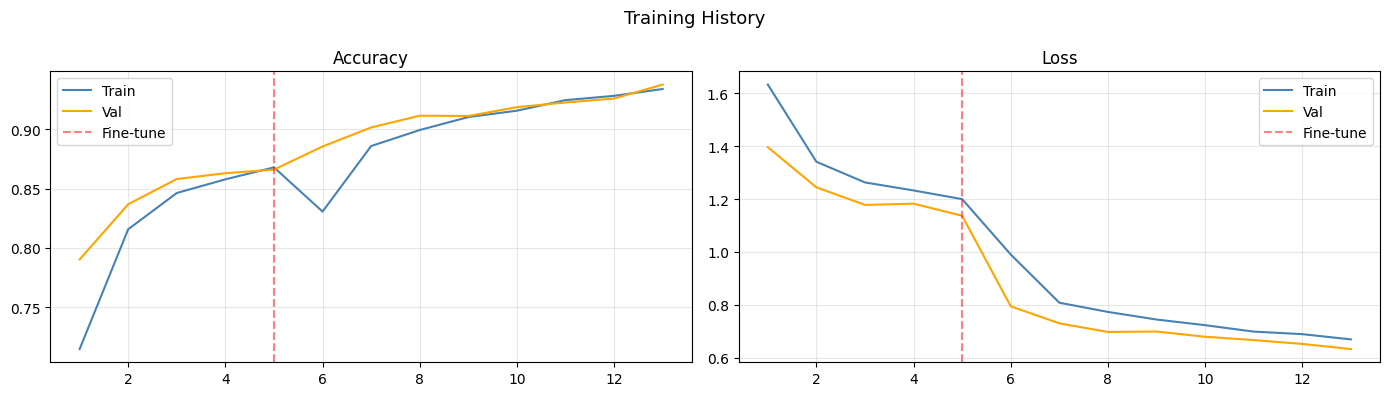

Final evaluation:
340/340 ━━━━━━━━━━━━━━━━━━━━ 13s 38ms/step - accuracy: 0.9377 - loss: 0.6320 - top3: 0.9908
Val accuracy : 93.77%
Top-3 acc    : 99.08%


In [ ]:
import matplotlib.pyplot as plt

a1, va1 = history1.history['accuracy'], history1.history['val_accuracy']
a2, va2 = history2.history['accuracy'], history2.history['val_accuracy']
l1, vl1 = history1.history['loss'],     history1.history['val_loss']
l2, vl2 = history2.history['loss'],     history2.history['val_loss']

all_a  = a1  + a2
all_va = va1 + va2
all_l  = l1  + l2
all_vl = vl1 + vl2
ep     = range(1, len(all_a) + 1)
split_ep = len(a1)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, train, val, title in [
    (axes[0], all_a,  all_va, 'Accuracy'),
    (axes[1], all_l,  all_vl, 'Loss')
]:
    ax.plot(ep, train, label='Train', color='steelblue')
    ax.plot(ep, val,   label='Val',   color='orange')
    ax.axvline(x=split_ep, color='red', linestyle='--', alpha=0.5, label='Fine-tune')
    ax.set_title(title)
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('Training History', fontsize=13)
plt.tight_layout()
plt.savefig('training_history.png', dpi=150, bbox_inches='tight')
plt.show()

print('Final evaluation:')
loss, acc, top3 = model.evaluate(val_ds, verbose=1)
print(f'Val accuracy : {acc*100:.2f}%')
print(f'Top-3 acc    : {top3*100:.2f}%')

In [ ]:
print('Computing OOD thresholds on validation set...')

all_probs = []
for imgs, _ in val_ds:
    preds = model.predict(imgs, verbose=0)
    all_probs.append(preds)

all_probs    = np.concatenate(all_probs, axis=0)
max_conf     = np.max(all_probs, axis=1)
eps          = 1e-10
entropy      = -np.sum(all_probs * np.log(all_probs + eps), axis=1)
norm_entropy = entropy / np.log(NUM_CLASSES)

print(f'\nValidation set stats (plant images):')
print(f'  Max confidence  — mean: {max_conf.mean():.3f}  p5: {np.percentile(max_conf, 5):.3f}')
print(f'  Norm entropy    — mean: {norm_entropy.mean():.3f}  p95: {np.percentile(norm_entropy, 95):.3f}')

CONFIDENCE_THRESHOLD = float(np.percentile(max_conf, 5))
ENTROPY_THRESHOLD    = float(np.percentile(norm_entropy, 95))

print(f'\nOOD thresholds:')
print(f'  CONFIDENCE_THRESHOLD : {CONFIDENCE_THRESHOLD:.4f}')
print(f'  ENTROPY_THRESHOLD    : {ENTROPY_THRESHOLD:.4f}')

Computing OOD thresholds on validation set...

Validation set stats (plant images):
  Max confidence  — mean: 0.863  p5: 0.387
  Norm entropy    — mean: 0.164  p95: 0.620

OOD thresholds:
  CONFIDENCE_THRESHOLD : 0.3872
  ENTROPY_THRESHOLD    : 0.6202


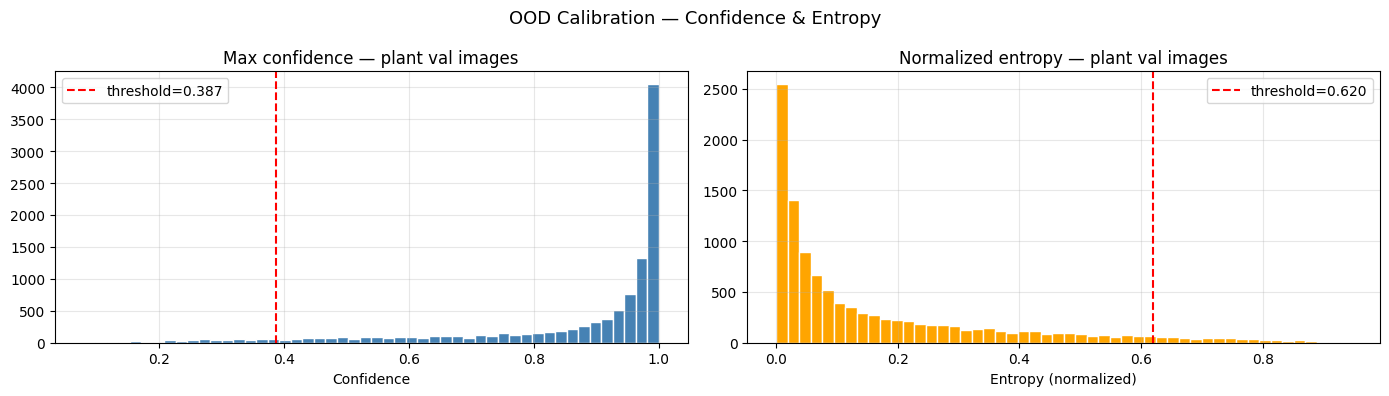

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(max_conf, bins=50, color='steelblue', edgecolor='white')
axes[0].axvline(CONFIDENCE_THRESHOLD, color='red', linestyle='--',
                label=f'threshold={CONFIDENCE_THRESHOLD:.3f}')
axes[0].set_title('Max confidence — plant val images')
axes[0].set_xlabel('Confidence')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].hist(norm_entropy, bins=50, color='orange', edgecolor='white')
axes[1].axvline(ENTROPY_THRESHOLD, color='red', linestyle='--',
                label=f'threshold={ENTROPY_THRESHOLD:.3f}')
axes[1].set_title('Normalized entropy — plant val images')
axes[1].set_xlabel('Entropy (normalized)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('OOD Calibration — Confidence & Entropy', fontsize=13)
plt.tight_layout()
plt.savefig('ood_calibration.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 8 — TTA Predictor

In [ ]:
from PIL import Image
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input


def load_and_preprocess(image_source):
    if isinstance(image_source, (str, os.PathLike)):
        img = Image.open(image_source)
    else:
        img = Image.open(io.BytesIO(image_source))
    img = img.convert('RGB').resize((224, 224))
    arr = np.array(img, dtype=np.float32)
    arr = preprocess_input(arr)
    return arr


def tta_augment(arr):
    img_t = tf.constant(arr)
    if random.random() > 0.5:
        img_t = tf.image.flip_left_right(img_t)
    img_t = tf.image.random_brightness(img_t, max_delta=0.05)
    img_t = tf.image.random_contrast(img_t, 0.95, 1.05)
    img_t = tf.clip_by_value(img_t, -1.0, 1.0)
    return img_t.numpy()


def predict_disease(
    image_source, model, idx_to_class_map,
    confidence_threshold, entropy_threshold,
    tta_steps=8, top_k=5, show_plot=True
):
    arr = load_and_preprocess(image_source)

    all_preds = []
    p = model.predict(np.expand_dims(arr, 0), verbose=0)[0]
    all_preds.append(p)
    for _ in range(tta_steps - 1):
        aug = tta_augment(arr)
        p   = model.predict(np.expand_dims(aug, 0), verbose=0)[0]
        all_preds.append(p)

    avg_preds    = np.mean(all_preds, axis=0)
    max_conf     = float(np.max(avg_preds))
    eps          = 1e-10
    entropy      = float(-np.sum(avg_preds * np.log(avg_preds + eps)))
    norm_entropy = entropy / np.log(len(avg_preds))
    is_plant     = (max_conf >= confidence_threshold) and (norm_entropy <= entropy_threshold)

    top_indices = np.argsort(avg_preds)[::-1][:top_k]
    top_results = [
        {'disease': idx_to_class_map[i], 'confidence': round(float(avg_preds[i]) * 100, 2)}
        for i in top_indices
    ]

    result = {
        'status'    : 'plant' if is_plant else 'not_a_plant',
        'disease'   : top_results[0]['disease'] if is_plant else None,
        'confidence': round(max_conf * 100, 2),
        'entropy'   : round(norm_entropy, 4),
        'top_k'     : top_results,
        'message'   : (
            f"Detected: {top_results[0]['disease']}  ({max_conf*100:.1f}% confidence)"
            if is_plant else
            'Not a plant leaf. Please upload a clear photo of a plant leaf.'
        )
    }

    if show_plot:
        if isinstance(image_source, (str, os.PathLike)):
            display_img = Image.open(image_source).convert('RGB')
        else:
            display_img = Image.open(io.BytesIO(image_source)).convert('RGB')

        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        axes[0].imshow(display_img)
        axes[0].axis('off')
        border_color = '#27ae60' if is_plant else '#e74c3c'
        axes[0].set_title(result['message'], color=border_color,
                          fontsize=10, fontweight='bold', wrap=True)

        names  = [r['disease'][:38] for r in top_results]
        scores = [r['confidence'] for r in top_results]
        colors = [border_color if i == 0 else '#95a5a6' for i in range(len(top_results))]

        bars = axes[1].barh(names, scores, color=colors)
        axes[1].set_xlim(0, 115)
        axes[1].set_xlabel('Confidence (%)')
        axes[1].set_title(f'Top {top_k} — TTA ({tta_steps} passes)\n'
                          f'entropy={norm_entropy:.3f}  conf={max_conf*100:.1f}%')
        for bar, score in zip(bars, scores):
            axes[1].text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
                         f'{score:.1f}%', va='center', fontsize=10)
        axes[1].invert_yaxis()
        axes[1].grid(axis='x', alpha=0.3)
        axes[1].axvline(confidence_threshold * 100, color='red', linestyle=':',
                        alpha=0.6, label=f'conf threshold={confidence_threshold*100:.1f}%')
        axes[1].legend(fontsize=8)
        plt.tight_layout()
        plt.show()

    return result


print('✅ predict_disease() defined with TTA + OOD detection')

✅ predict_disease() defined with TTA + OOD detection


## Step 9 — Test Plant + Non-Plant Images

=== TEST A: Plant leaf images (should classify correctly) ===

True class: Tomato___Tomato_mosaic_virus


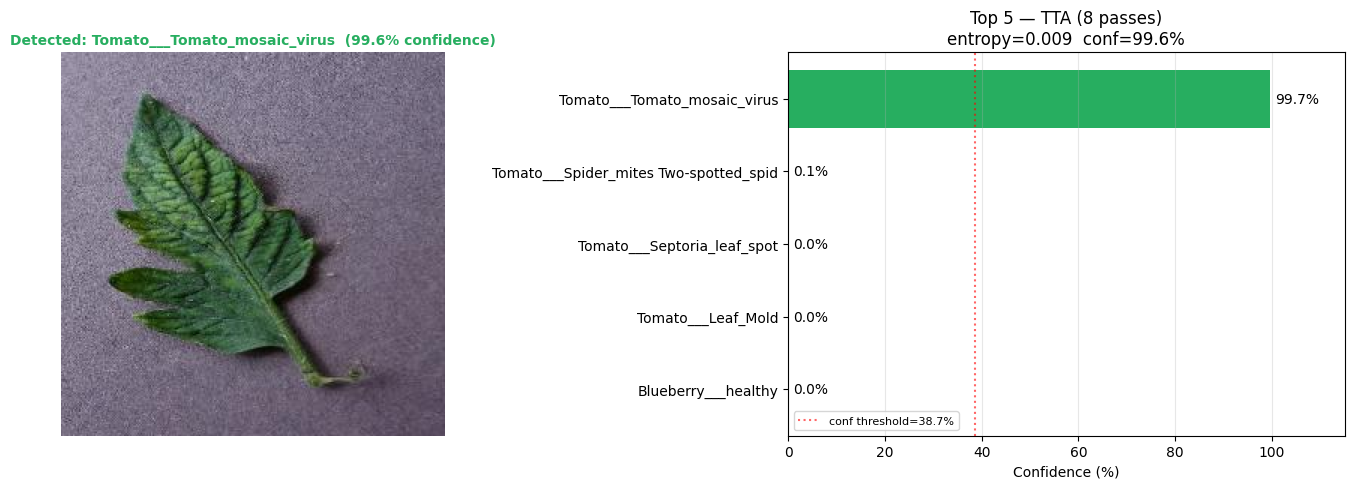

Result    : Detected: Tomato___Tomato_mosaic_virus  (99.6% confidence)
Status    : plant  entropy=0.0091

------------------------------------------------------------
True class: Blueberry___healthy


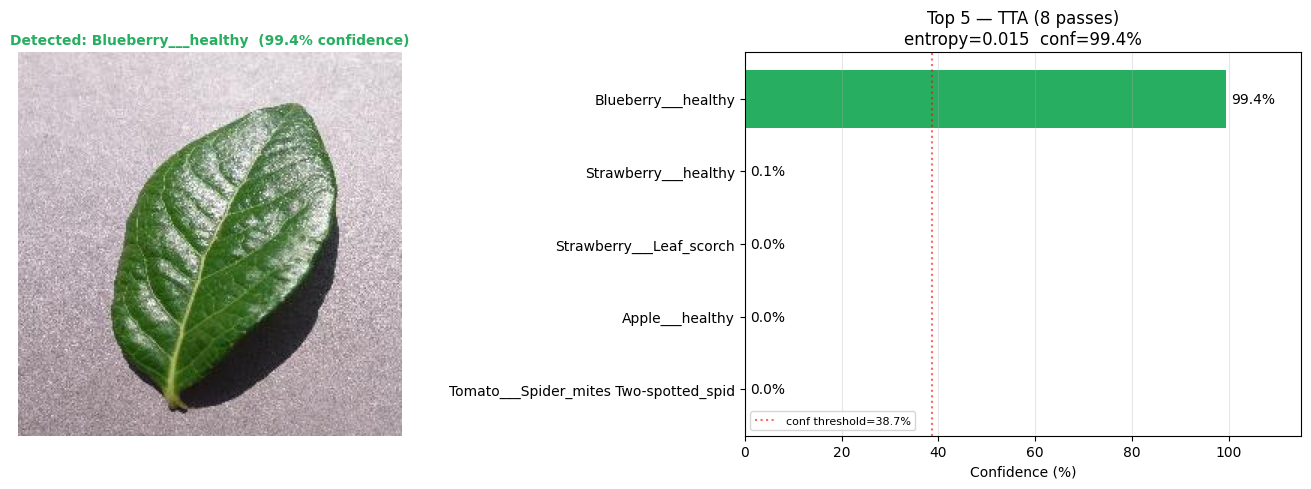

Result    : Detected: Blueberry___healthy  (99.4% confidence)
Status    : plant  entropy=0.0148

------------------------------------------------------------
True class: Grape___healthy


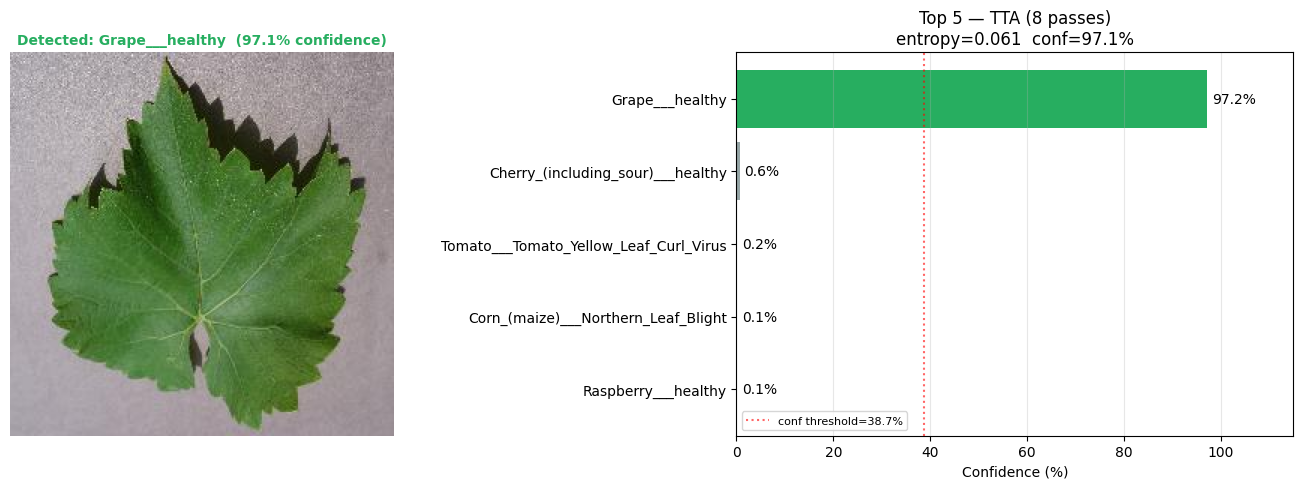

Result    : Detected: Grape___healthy  (97.1% confidence)
Status    : plant  entropy=0.0609

------------------------------------------------------------


In [ ]:
print('=== TEST A: Plant leaf images (should classify correctly) ===\n')

for _ in range(3):
    rc   = random.choice(classes)
    rdir = os.path.join(BASE_DIR, rc)
    rimg = os.path.join(rdir, random.choice(os.listdir(rdir)))

    print(f'True class: {rc}')
    result = predict_disease(
        rimg, model, idx_to_class,
        CONFIDENCE_THRESHOLD, ENTROPY_THRESHOLD,
        tta_steps=8, top_k=5
    )
    print(f'Result    : {result["message"]}')
    print(f'Status    : {result["status"]}  entropy={result["entropy"]}\n')
    print('-' * 60)

=== TEST B: Non-plant images (should be REJECTED) ===

Input: Pure noise (random pixels)


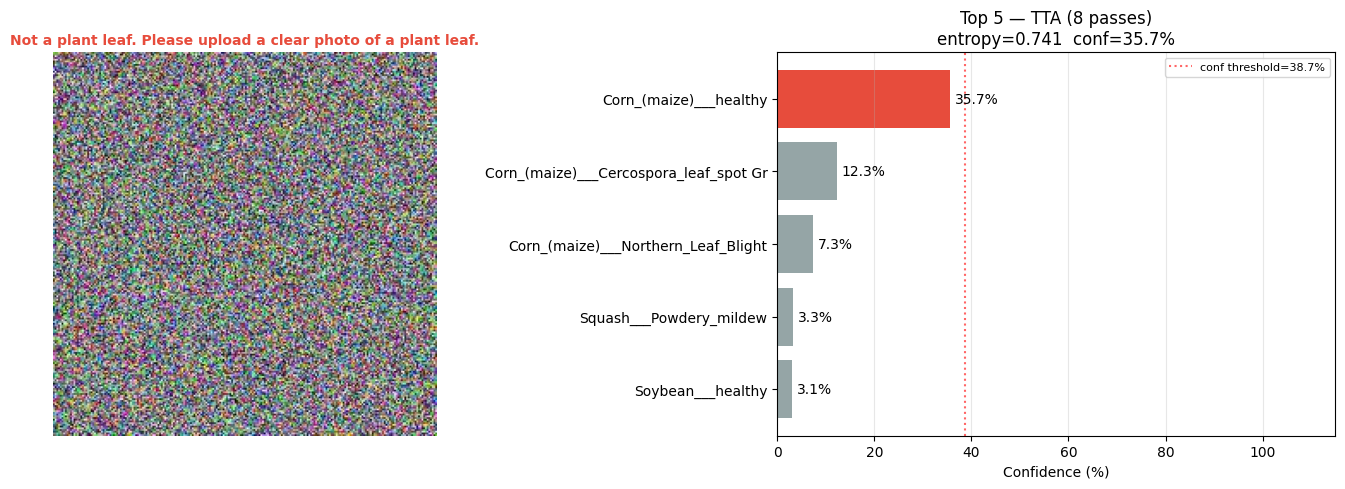

Status : not_a_plant  conf=35.68%  entropy=0.7409
Message: Not a plant leaf. Please upload a clear photo of a plant leaf.

------------------------------------------------------------
Input: Solid blue (blue sky photo)


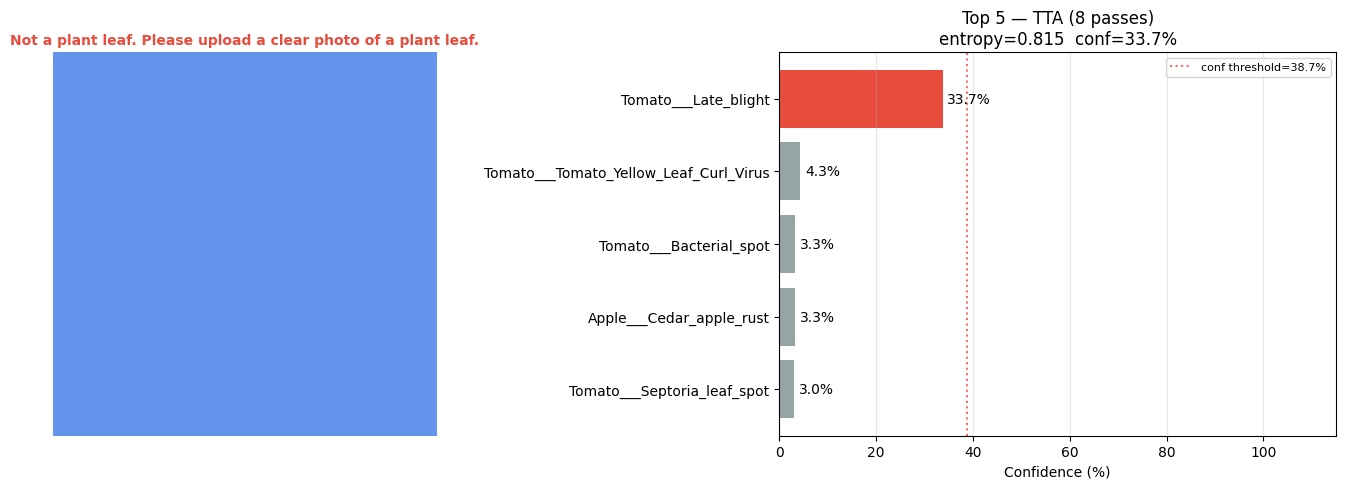

Status : not_a_plant  conf=33.73%  entropy=0.8152
Message: Not a plant leaf. Please upload a clear photo of a plant leaf.

------------------------------------------------------------
Input: Solid skin tone (selfie-like)


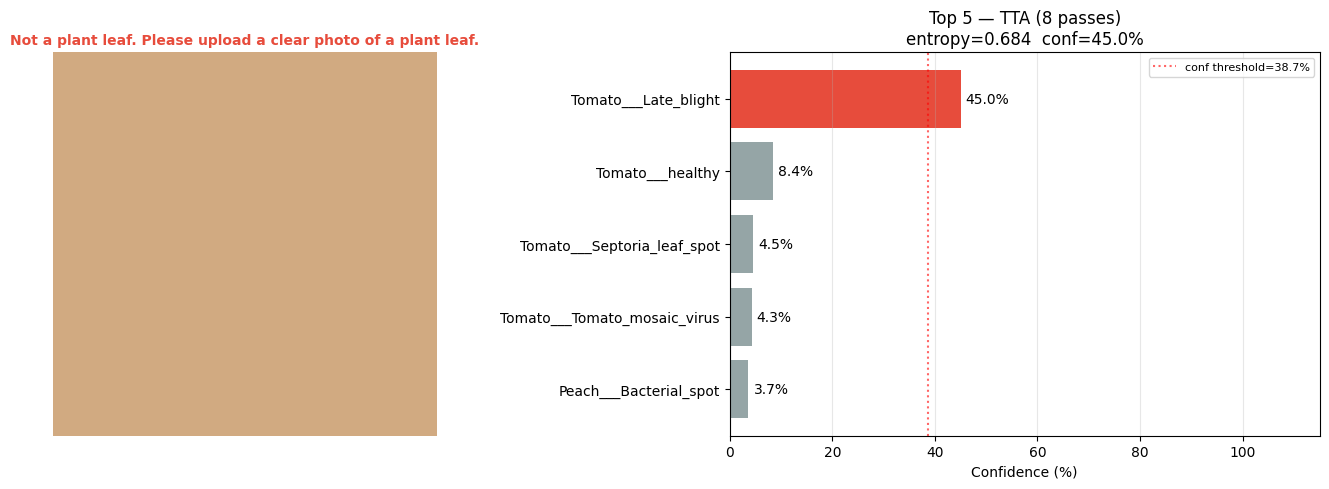

Status : not_a_plant  conf=45.02%  entropy=0.6843
Message: Not a plant leaf. Please upload a clear photo of a plant leaf.

------------------------------------------------------------


In [ ]:
import tempfile

print('=== TEST B: Non-plant images (should be REJECTED) ===\n')

test_cases = [
    ('Pure noise (random pixels)',    np.random.randint(0, 255, (224, 224, 3), dtype=np.uint8)),
    ('Solid blue (blue sky photo)',   np.full((224, 224, 3), [100, 149, 237], dtype=np.uint8)),
    ('Solid skin tone (selfie-like)', np.full((224, 224, 3), [210, 170, 130], dtype=np.uint8)),
]

for name, arr in test_cases:
    print(f'Input: {name}')
    with tempfile.NamedTemporaryFile(suffix='.jpg', delete=False) as tmp:
        Image.fromarray(arr).save(tmp.name)
        tmp_path = tmp.name
    result = predict_disease(
        tmp_path, model, idx_to_class,
        CONFIDENCE_THRESHOLD, ENTROPY_THRESHOLD,
        tta_steps=8, top_k=5, show_plot=True
    )
    print(f'Status : {result["status"]}  conf={result["confidence"]}%  entropy={result["entropy"]}')
    print(f'Message: {result["message"]}\n')
    print('-' * 60)
    os.unlink(tmp_path)

## Step 10 — Save Model

In [ ]:
# ── Save model ──
MODEL_PATH = 'plant_disease_model.keras'
model.save(MODEL_PATH)
size_mb = os.path.getsize(MODEL_PATH) / (1024 * 1024)
print(f'Model saved: {MODEL_PATH}  ({size_mb:.1f} MB)')

# ── Save class names ──
with open('class_names.json', 'w') as f:
    json.dump(class_names_export, f, indent=2)
print('Saved: class_names.json')

# ── Save model metadata ──
import keras as _keras
keras_version = _keras.__version__
tf_version    = tf.__version__

meta = {
    'model_file'           : 'plant_disease_model.keras',
    'input_size'           : [224, 224, 3],
    'preprocessing'        : 'mobilenet_v2.preprocess_input — scales pixel [0,255] to [-1,1]',
    'num_classes'          : NUM_CLASSES,
    'val_accuracy'         : round(float(max(history2.history['val_accuracy'])), 4),
    'tta_steps'            : 8,
    'confidence_threshold' : round(CONFIDENCE_THRESHOLD, 4),
    'entropy_threshold'    : round(ENTROPY_THRESHOLD, 4),
    'ood_rejection_rule'   : 'reject if max_confidence < confidence_threshold OR normalized_entropy > entropy_threshold',
    'trained_with_tf'      : tf_version,
    'trained_with_keras'   : keras_version,
}
with open('model_meta.json', 'w') as f:
    json.dump(meta, f, indent=2)
print('Saved: model_meta.json')
print()
print('--- Final Summary ---')
for k, v in meta.items():
    print(f'  {k:30s}: {v}')

Model saved: plant_disease_model.keras  (31.2 MB)
Saved: class_names.json
Saved: model_meta.json

--- Final Summary ---
  model_file                    : plant_disease_model.keras
  input_size                    : [224, 224, 3]
  preprocessing                 : mobilenet_v2.preprocess_input — scales pixel [0,255] to [-1,1]
  num_classes                   : 38
  val_accuracy                  : 0.9377
  tta_steps                     : 8
  confidence_threshold          : 0.3872
  entropy_threshold             : 0.6202
  ood_rejection_rule            : reject if max_confidence < confidence_threshold OR normalized_entropy > entropy_threshold
  trained_with_tf               : 2.19.0
  trained_with_keras            : 3.13.2


In [ ]:
# ── Verify reload ──
reloaded = tf.keras.models.load_model('plant_disease_model.keras')

rc   = random.choice(classes)
rimg = os.path.join(BASE_DIR, rc, random.choice(os.listdir(os.path.join(BASE_DIR, rc))))
arr  = load_and_preprocess(rimg)
inp  = np.expand_dims(arr, 0)

orig_pred     = idx_to_class[int(np.argmax(model.predict(inp, verbose=0)[0]))]
reloaded_pred = idx_to_class[int(np.argmax(reloaded.predict(inp, verbose=0)[0]))]

print(f'True class       : {rc}')
print(f'Original model   : {orig_pred}')
print(f'Reloaded model   : {reloaded_pred}')
print(f'Predictions match: {orig_pred == reloaded_pred}')
assert orig_pred == reloaded_pred, '❌ Model reload mismatch!'
print('\n✅ Model verified — safe to deploy')

True class       : Tomato___Tomato_mosaic_virus
Original model   : Tomato___Tomato_mosaic_virus
Reloaded model   : Tomato___Tomato_mosaic_virus
Predictions match: True

✅ Model verified — safe to deploy


## Step 11 — Download Everything

In [ ]:
from google.colab import files

download_list = [
    # Model files → goes into model/ folder on HF
    ('plant_disease_model.keras', 'model/'),
    ('class_names.json',          'model/'),
    ('model_meta.json',           'model/'),
    # Plots (optional)
    ('training_history.png', 'optional/'),
    ('ood_calibration.png',  'optional/'),
]

print('Downloading files...\n')
for fname, dest in download_list:
    if os.path.exists(fname):
        files.download(fname)
        print(f'  ✅  {fname:40s} → put in {dest}')
    else:
        print(f'  ⚠️  {fname} not found — skipping')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  ✅  plant_disease_model.keras                → put in model/


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

  ✅  training_history.png                     → put in optional/


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  ✅  ood_calibration.png                      → put in optional/

HUGGINGFACE SPACE FOLDER STRUCTURE

your-hf-space/
├── Dockerfile           ← Python 3.12, installs deps as root
├── requirements.txt     ← pinned tf + keras versions
├── main.py              ← FastAPI app
├── utils.py             ← preprocessing helper
├── .gitignore           ← excludes .keras from git
└── model/
    ├── plant_disease_model.keras   ← upload via HF UI (large file)
    ├── class_names.json
    └── model_meta.json

UPLOAD STEPS

1. Create a new HuggingFace Space
   → huggingface.co/new-space
   → SDK: Docker

2. Upload all files EXCEPT the .keras model:
   → Drag & drop via the Files tab in HF UI
   OR git push (model is in .gitignore)

3. Upload plant_disease_model.keras separately:
   → Files tab → Upload file → model/plant_disease_model.keras
   (HF handles large files with Git LFS automatically)

4. Space will auto-build and deploy!
   → Build logs: Settings > Logs
   → Test at: your-space.hf.space/do